# Zadanie 1

W ćwiczeniu 1 przeprowadziliśmy eksperyment pokazujący, jak intensywność mutacji – **wielkość sąsiedztwa** – wpływa na rezultaty optymalizacji. W tym ćwiczeniu sprawdzimy bardziej szczegółowo, jak na rezultaty wpływają poszczególne rodzaje mutacji – **kształt sąsiedztwa**.

We wcześniejszych zadaniach mieliśmy do czynienia jedynie z aspektem kombinatorycznym optymalizacji – bez elementów numerycznych (ciągłych). Ponadto optymalizowaliśmy jedynie konstrukcje statyczne, pasywne, nie reagujące na otoczenie i na własny stan. Teraz do samej konstrukcji dołączymy elementy aktywne. Potrzebujemy sensorów (receptorów) do pobierania informacji ze środowiska (lub z samej konstrukcji) oraz aktuatorów (efektorów) do wpływania na nie (lub na samą konstrukcję). Przydadzą się też jakieś elementy logiki przetwarzające sygnał (reguły, neurony itp.).

W środowisku Framsticks mamy do dyspozycji szereg symulowanych sensorów i aktuatorów; można też tworzyć własne. Nam do prostych eksperymentów będą potrzebne tylko dwa już istniejące typy receptorów (oznaczane symbolami `G` i `T`) oraz dwa typy efektorów (symbole `@` i `|`). Oprócz tego przydadzą się nam dwa typy generatorów (`Sin` – generator przebiegu sinusoidalnego oraz `*` – generator sygnału o wartości 1). Neurony, receptory i efektory oprócz swojego typu mają też swoje indywidualne parametry, więc nie każdy neuron danego typu musi być identyczny.

Żeby optymalizowane w dalszych eksperymentach konstrukcje i sieci neuronowe nie były tajemnicze i niezrozumiałe ("ewolucja coś zoptymalizowała"), poznamy sposób zakodowania neuronów na przykładzie reprezentacji **f1** oraz przetestujemy interakcyjnie sposób ich działania podczas symulacji. W tym celu zaczniemy od przećwiczenia rozdziałów I.4, I.5 i I.6 (do ćwiczenia 1 włącznie) z [tutoriala](https://www.framsticks.com/common/tutorial/index_pl.html).

Zanim przeprowadzimy nienadzorowane eksperymenty ewolucyjne optymalizując sieć neuronową, najpierw zaobserwujmy bardziej interakcyjnie, co robi ewolucja z siecią neuronową realizując punkt II.1 tutoriala i sukcesywnie zwiększając sąsiedztwo.

W odpowiedzi wpisz uzyskane prędkości:

- w I.6, Ćwiczenie 1 (ręczna manipulacja dwoma parametrami)
- w II.1, mutacja tylko wag neuronów i ich własności
- w II.1, + mutacja modyfikatora długości stick'ów
- w II.1, + mutacje: dodawanie i usuwanie neuronów, sensorów i efektorów

Jakie powiększenie sąsiedztwa pozwoliło na największy przyrost prędkości?

Czy optymalizacja zmieniła kształt konstrukcji poprzez modyfikację długości segmentów?

### Osiągnięte maksymalne stabilne wartości prędkości

| Eksperyment | Maksymalna prędkość |
|------------|---------------------|
| I.6, Ćwiczenie 1 | 0.0021678136 |
| II.1, mutacja tylko wag neuronów i ich własności | 0.0021519504 |
| II.1, + mutacja modyfikatora długości stick'ów | 0.0036117859 |
| II.1, + mutacje: dodawanie i usuwanie neuronów, sensorów i efektorów | 0.0028934839 |

- Największy przyrost prędkości uzyskano, gdy mutacja dotyczyła tylko długości sticków. Prawdopodobnie znaczy to, że początkowa konstrukcja była już dobrze zoptymalizowana pod kątem umiejscowienia i sposobu działania mięśni.
- Kształt konstrukcji zmienił się nieznacznie przez modyfikację długości sticków.


# Zadanie 2

W następnym pytaniu będziemy optymalizować prędkość poruszania się konstrukcji, jednak prędkość trzeba jakoś wyznaczyć. Wiemy, że prędkość=droga/czas, i czas liczymy w krokach symulacji. Jednak `czas` ma dwie interpretacje. Pierwsza to czas symulacji danej konstrukcji (w terminologii Framsticks to `lifespan` i załóżmy, że jest ustalony i go nie zmieniamy). Druga to odstęp między momentami, między którymi wyznaczamy drogę (w terminologii Framsticks to `perfperiod` – skrót od "performance sampling period").

Zakładając, że każda konstrukcja jest symulowana przez 10 000 kroków (to jest `lifespan`), możemy `perfperiod` ustawić właśnie na 10 000 kroków, ale możemy też ustawić na 2 000 i w trakcie całego `lifespan` policzyć pięć prędkości, które potem uśrednimy. Albo możemy ustawić `perfperiod` na 20 i policzyć 500 prędkości, które potem uśrednimy. Za każdym razem dostaniemy ostatecznie jedną wartość prędkości, ale inaczej zdefiniowanej – zobacz ten [schemat](https://www.framsticks.com/a/al_params.html#exper-perfcalc). ❶ A jak w fizyce nazywa się prędkość, gdy `perfperiod` dąży do zera?

Wyobraź sobie teraz przestrzeń wszystkich możliwych genotypów, a nad nią unoszący się krajobraz przystosowania dany właśnie wartością prędkości. Teraz wyobraź sobie, że tych krajobrazów jest wiele, każdy dla innej wartości `perfperiod`. Czym one się różnią? ❷ Co się dzieje z krajobrazem, gdy `perfperiod` płynnie rośnie począwszy od minimalnej wartości? ❸ Czy wszystkie krajobrazy mają jakieś punkty wspólne, a jeśli tak, to jaki dokładnie rodzaj ruchu tworzy takie punkty? ❹ Czy krajobrazy różnią się łatwością optymalizacyjnego odkrycia bardzo dobrych rozwiązań (w danym krajobrazie) i dlaczego? ("bardzo dobrych" abstrahuje zupełnie od tego, jak nam się subiektywnie jakiś rodzaj ruchu podoba – chodzi o sam krajobraz i bardzo dobre wartości funkcji celu).

Uwaga – możesz opcjonalnie zweryfikować, czy twoje wyobrażenie krajobrazów i ich trudności było poprawne: przygotuj kilkadziesiąt poruszających się w różny sposób konstrukcji i oceń je ustawiając różne `perfperiod` (nie zmieniając `lifespan`), a następnie narysuj wykres: oś pozioma = poszczególne genotypy, oś pionowa = `velocity` dla różnych `frams.Populations[0].perfperiod` (kilka wartości od 1 do `lifespan`).

1.  Gdy wartość parametru `perfperiod` dąży do zera, mierzona prędkość odpowiada w fizyce **prędkości chwilowej**.
2. Zmiana wartości `perfperiod` w istotny sposób wpływa na kształt krajobrazu przystosowania.  
Dla **małych wartości `perfperiod`** prędkość jest liczona na bardzo krótkich odcinkach czasu, co powoduje dużą wrażliwość na chwilowe fluktuacje ruchu. W efekcie krajobraz przystosowania staje się **chropowaty**, zawiera liczne lokalne ekstrema i jest silnie zaszumiony.  
Wraz ze **wzrostem wartości `perfperiod`** prędkość jest coraz silniej uśredniana w czasie, co prowadzi do **wygładzenia krajobrazu przystosowania** i redukcji wpływu krótkotrwałych, przypadkowych ruchów.
3. Niezależnie od wartości `perfperiod`, krajobrazy przystosowania mają punkty wspólne. Są nimi przede wszystkim genotypy odpowiadające konstrukcjom **nieruchomym** (prędkość równa zero) oraz konstrukcjom poruszającym się **ruchem stabilnym i powtarzalnym**, których średnia prędkość pozostaje zbliżona niezależnie od sposobu próbkowania.
4. Krajobrazy uzyskane dla **większych wartości `perfperiod`** są zazwyczaj **łatwiejsze do optymalizacji**, ponieważ są gładsze i mniej podatne na lokalne fluktuacje funkcji celu.  
Dla **małych wartości `perfperiod`** krajobraz jest bardziej chropowaty, co zwiększa ryzyko utknięcia algorytmu optymalizacyjnego w lokalnych ekstremach i utrudnia odnalezienie bardzo dobrych rozwiązań.


# Zadanie 3

Pora na eksperyment ewolucyjny. Wybierz jedną z reprezentacji (**f0** lub **f1**) i przeprowadź optymalizację prędkości poruszania się wedle następującego schematu:

```bash
for %%P in (0) do (
    for /L %%N in (1,1,10) do (
        python FramsticksEvolution.py -path %DIR_WITH_FRAMS_LIBRARY%  -sim "eval-allcriteria.sim;deterministic.sim;sample-period-longest.sim;wlasne-prawd-%%P.sim"    -opt velocity   -max_numparts 15   -max_numjoints 30    -max_numneurons 20    -max_numconnections 30   -genformat WYBRANY-0-LUB-1   -pxov 0   -popsize rozmiarconajmniej50    -generations odpowiedniadlugosc   -hof_size 1    -hof_savefile HoF-vel-prawd-%%P-%%N.gen
    ))
```

Wyniki powyższego eksperymentu będą stanowiły poziom odniesienia. Pętla nadrzędna z `%%P` jest na razie nadmiarowa. Żeby uniknąć wyjątku przy próbie wczytania brakującego pliku `wlasne-prawd-0.sim`, stwórz pusty plik o tej nazwie w podkatalogu `data/`.

Jak wiemy, ze względu na różnorodność elementów konstrukcji, które muszą podlegać ewolucji, potrzebujemy różnych operatorów mutacji. Jest to zupełnie odmienne od np. problemu permutacyjnego typu TSP, gdzie mieliśmy ściśle określone, jednorodne, skończone sąsiedztwo. Tutaj mamy wiele sposobów na generowanie sąsiada (mutanta) i każdy z nich ma swoje prawdopodobieństwo wystąpienia.

In [1]:
import subprocess
import sys
from pathlib import Path


def run_velocity_experiments(genformat=1, popsize=50, generations=100):
    FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
    LIB_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53")
    FS_SCRIPT = FRAMSPY_DIR / "FramsticksEvolution.py"

    opt = "velocity"

    max_numparts = "15"
    max_numjoints = "30"
    max_numneurons = "20"
    max_numconnections = "30"

    results_dir = FRAMSPY_DIR / "results" / "velocity_mutation_experiments"
    hof_dir = results_dir / "HallOfFame"

    results_dir.mkdir(parents=True, exist_ok=True)
    hof_dir.mkdir(parents=True, exist_ok=True)

    # P = 0 → benchmark
    # P = 1 → all probabilities = 1
    # P = 2 → domain knowledge
    for P in (0, 1, 2):
        sim_files = (
            "eval-allcriteria.sim;"
            "deterministic.sim;"
            "sample-period-longest.sim;"
            f"wlasne-prawd-{P}.sim"
        )

        for run_id in range(1, 11):
            hof_file = hof_dir / f"HoF-vel-prawd-{P}-f{genformat}-{run_id}.gen"
            results_file = results_dir / f"results-vel-prawd-{P}-f{genformat}-{run_id}.txt"

            args = [
                sys.executable,
                str(FS_SCRIPT),
                "-path", str(LIB_DIR),
                "-sim", sim_files,
                "-opt", opt,
                "-genformat", str(genformat),
                "-pxov", "0",
                "-popsize", str(popsize),
                "-generations", str(generations),
                "-max_numparts", max_numparts,
                "-max_numjoints", max_numjoints,
                "-max_numneurons", max_numneurons,
                "-max_numconnections", max_numconnections,
                "-hof_size", "1",
                "-hof_savefile", str(hof_file),
            ]

            with results_file.open("w", encoding="utf-8") as fout:
                try:
                    subprocess.run(
                        args,
                        cwd=str(FRAMSPY_DIR),
                        stdout=fout,
                        stderr=subprocess.STDOUT,
                        check=True,
                    )
                except subprocess.CalledProcessError as e:
                    print(f"[P={P}, run={run_id}] ERROR ({e.returncode})")
                except Exception as e:
                    print(f"[P={P}, run={run_id}] UNEXPECTED ERROR: {e}")

In [2]:
run_velocity_experiments()

In [3]:
def run_dynamic_experiment(genformat=1, popsize=50, generations=100):
    FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
    LIB_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/Framsticks53")
    FS_SCRIPT = FRAMSPY_DIR / "FramsticksEvolution.py"

    opt = "velocity"

    phase_generations = generations // 3
    extra_generations = 5

    results_dir = FRAMSPY_DIR / "results" / "velocity_mutation_experiments"
    hof_dir = results_dir / "HallOfFame"
    results_dir.mkdir(parents=True, exist_ok=True)
    hof_dir.mkdir(parents=True, exist_ok=True)

    for run_id in range(1, 11):
        previous_best_genotype = None

        for phase in (1, 2, 3):
            sim_files = (
                "eval-allcriteria.sim;"
                "deterministic.sim;"
                "sample-period-longest.sim;"
                f"wlasne-prawd-3-{phase}.sim"
            )

            hof_file = hof_dir / f"HoF-vel-prawd-3-p{phase}-f{genformat}-{run_id}.gen"
            results_file = results_dir / f"results-vel-prawd-3-p{phase}-f{genformat}-{run_id}.txt"

            gens = phase_generations
            if previous_best_genotype is not None:
                gens += extra_generations

            args = [
                sys.executable,
                str(FS_SCRIPT),
                "-path", str(LIB_DIR),
                "-sim", sim_files,
                "-opt", opt,
                "-genformat", str(genformat),
                "-pxov", "0",
                "-popsize", str(popsize),
                "-generations", str(gens),
                "-hof_size", "1",
                "-hof_savefile", str(hof_file),
            ]

            if previous_best_genotype is not None:
                args += ["-initialgenotype", previous_best_genotype]

            with results_file.open("w", encoding="utf-8") as fout:
                subprocess.run(
                    args,
                    cwd=str(FRAMSPY_DIR),
                    stdout=fout,
                    stderr=subprocess.STDOUT,
                    check=True,
                )

            with hof_file.open("r", encoding="utf-8") as f:
                for line in f:
                    line = line.strip()
                    if line.startswith("genotype:"):
                        previous_best_genotype = line[len("genotype:"):].strip()
                        break

In [4]:
run_dynamic_experiment()

Włącz Framsticks GUI, wybierz w menu: File→Open (Ctrl-O) i wczytaj plik `eval-allcriteria.sim`, wybierz w menu: Simulation→Parameters (Ctrl-P), po lewej w drzewku rozwiń "Genetics" i dalej rozwiń gałęzie "f0" oraz "f1". W podgałęziach widzisz wartości (nie muszą sumować się do 1), które są względnymi prawdopodobieństwami poszczególnych operacji wykonywanych na genotypie. One wpływają na sposób poruszania się po topologii przeszukiwania. Zawsze w ramach pojedynczej mutacji wykonywana jest jedna wybrana operacja (jest ona wybierana metodą ruletki właśnie na podstawie tych względnych prawdopodobieństw). Zerknij teraz na plik `eval-allcriteria.sim` – znajdziesz tam sekcję parametrów zaczynającą się od `f0_p_new`, a nieco niżej sekcję zaczynającą się od `f1_smX`. W zależności od tego, czy wybrałeś/aś **f0** czy **f1**, skopiuj te parametry, które są liczbowe do nowego pliku, np. `wlasne-prawd-1.sim` – nie zapominając, że pierwszą linią przed sekcją parametrów musi być `sim_params`: (bez pustych linii pomiędzy).

Teraz zmienimy sposób przeszukiwania topologii zbioru rozwiązań. Przeprowadź kolejny eksperyment ustawiając wszystkie prawdopodobieństwa w swoim pliku `wlasne-prawd-1.sim` na taką samą wartość, na przykład 1. Wyobraź sobie, jakie ta zmiana powoduje konsekwencje dla ewolucji. Wygeneruj te wykresy, co zwykle. Czy udało się uzyskać lepsze ostateczne wyniki, czy te wyniki się nie zmieniły, czy też pogorszyły się? O czym to świadczy? Teraz dobierz wartości prawdopodobieństw zgodnie ze swoją intuicją i wiedzą o tym, co robią poszczególne operatory, zapisz je w nowym pliku `wlasne-prawd-2.sim`, powtórz eksperyment i wygeneruj wykresy. Czy dały lepsze wyniki? Możesz przetestować więcej różnych zestawów prawdopodobieństw, jeśli chcesz zweryfikować inne swoje pomysły i hipotezy.

Na koniec spróbuj, bazując na swoich przypuszczeniach i dotychczasowym doświadczeniu, zmieniać prawdopodobieństwa operatorów podczas działania ewolucji. Zapewne przewidujesz, że różne operatory mają mniejszą lub większą użyteczność na początku lub na końcu procesu optymalizacji. Podobnie jak na pierwszych laboratoriach, po wykonaniu we `FramsticksEvolution.py` polecenia `import frams` masz dostęp do parametrów-obiektów `frams.GenMan.f0_p_new`, `frams.GenMan.f1_smX` itd. Możesz bezpiecznie zmieniać ich wartości w trakcie działania ewolucji, na przykład uzależniając ich zmiany od licznika wywołań funkcji `frams_evaluate()`, od liczby pokoleń, od najlepszej albo średniej wartości fitness w populacji, itp.

Wygeneruj wykresy i załącz je wszystkie w odpowiedzi. Opisz szczegółowo swoje pomysły dotyczące dostosowanych i zmiennych prawdopodobieństw. Czy Twoje przewidywania i pomysły na zmianę sposobu, w jaki ewolucja przeszukuje topologię zbioru rozwiązań przyniosły polepszenie ostatecznych wyników?

In [5]:
import os
import re
import pandas as pd
from pathlib import Path

FRAMSPY_DIR = Path(r"C:/Users/mikol/Desktop/Mikolaj/Studia/Informatyka/sem9/AMEBA/framspy")
results_folder = FRAMSPY_DIR / "results" / "velocity_mutation_experiments"

files = [
    f for f in os.listdir(results_folder)
    if f.startswith("results-vel-prawd") and f.endswith(".txt")
]

pattern_static = re.compile(r"results-vel-prawd-(\d+)-f(\d+)-(\d+)\.txt")
pattern_dynamic = re.compile(r"results-vel-prawd-3-p(\d+)-f(\d+)-(\d+)\.txt")

static_data = []
dynamic_raw = {}
times_data = {}
dynamic_times = {}

for file_name in files:
    m_static = pattern_static.match(file_name)
    m_dynamic = pattern_dynamic.match(file_name)

    if m_static:
        P, genformat, iteration = m_static.groups()
        P = int(P)
        iteration = int(iteration)
        phase = None
    elif m_dynamic:
        phase, genformat, iteration = m_dynamic.groups()
        P = 3
        phase = int(phase)
        iteration = int(iteration)
    else:
        continue

    path = results_folder / file_name
    with open(path, "r", encoding="utf-8") as f:
        lines = f.readlines()

    start_index = None
    for i, line in enumerate(lines):
        if line.strip().startswith("gen"):
            start_index = i
            break
    if start_index is None:
        continue

    rows = []
    for row in lines[start_index + 1:]:
        parts = re.split(r"\s+", row.strip())
        if len(parts) < 6:
            continue
        try:
            rows.append({
                "gen": int(parts[0]),
                "nevals": int(parts[1]),
                "avg": float(parts[2]),
                "stddev": float(parts[3]),
                "min": float(parts[4]),
                "max": float(parts[5]),
            })
        except ValueError:
            continue

    if P == 3:
        dynamic_raw.setdefault(iteration, {}).setdefault(phase, []).extend(rows)
    else:
        for r in rows:
            static_data.append({
                **r,
                "variant": P,
                "iteration": iteration
            })

    for line in lines[start_index + 1:]:
        if "Evolution execution time:" in line:
            try:
                t = float(line.strip().split()[-2])
            except ValueError:
                break
            if P == 3:
                dynamic_times.setdefault(iteration, 0.0)
                dynamic_times[iteration] += t
            else:
                times_data.setdefault((P, iteration), 0.0)
                times_data[(P, iteration)] += t
            break

all_data = static_data.copy()

for iteration, phases in dynamic_raw.items():
    gen_offset = 0
    neval_offset = 0

    for phase in (1, 2, 3):
        if phase not in phases:
            continue

        rows = phases[phase]
        if phase in (2, 3):
            rows = rows[6:]

        for r in rows:
            gen_offset += 1
            neval_offset += r["nevals"]
            all_data.append({
                "gen": gen_offset,
                "nevals": r["nevals"],
                "avg": r["avg"],
                "stddev": r["stddev"],
                "min": r["min"],
                "max": r["max"],
                "variant": 3,
                "iteration": iteration,
                "cumulative_nevals": neval_offset
            })

df = pd.DataFrame(all_data)

mask = df["variant"] != 3
df.loc[mask, "cumulative_nevals"] = (
    df[mask]
    .groupby(["variant", "iteration"])["nevals"]
    .cumsum()
)

df.to_csv("velocity_results.csv", index=False)

final_times = []
for (P, iteration), t in times_data.items():
    final_times.append({
        "variant": P,
        "iteration": iteration,
        "elapsed_time": t
    })

for iteration, t in dynamic_times.items():
    final_times.append({
        "variant": 3,
        "iteration": iteration,
        "elapsed_time": t
    })

pd.DataFrame(final_times).to_csv("velocity_times.csv", index=False)


### Wykresy

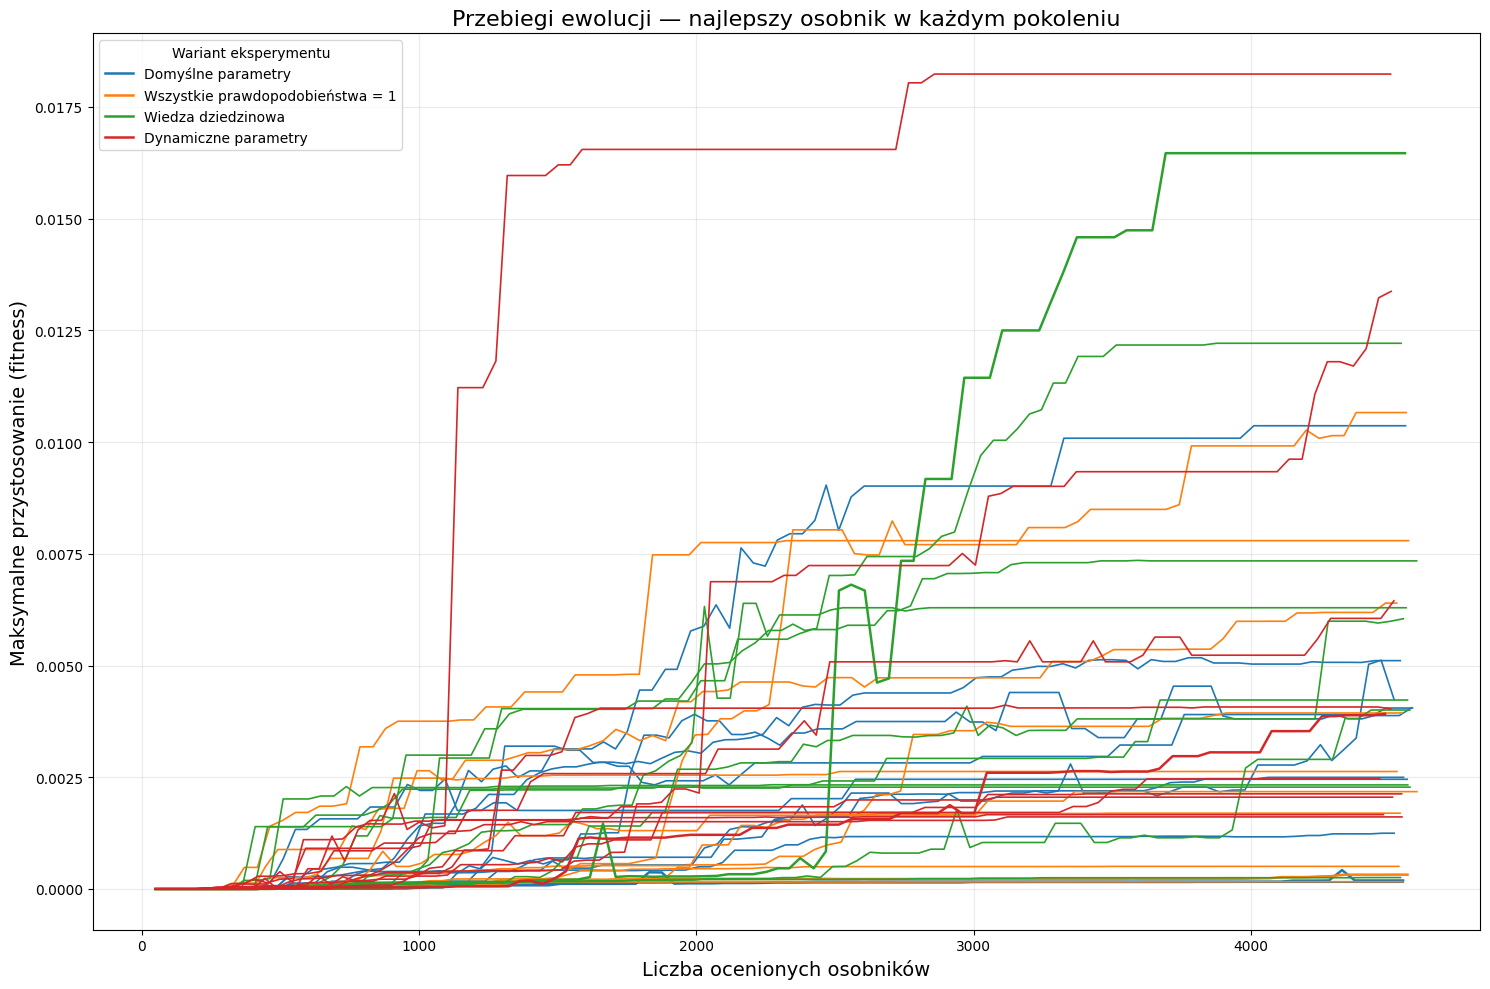

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("velocity_results.csv")

plt.figure(figsize=(15, 10), dpi=100)

variant_labels = {
    0: "Domyślne parametry",
    1: "Wszystkie prawdopodobieństwa = 1",
    2: "Wiedza dziedzinowa",
    3: "Dynamiczne parametry"
}

palette = sns.color_palette("tab10", n_colors=len(variant_labels))

for variant, color in zip(sorted(variant_labels), palette):
    iters = sorted(df[df["variant"] == variant]["iteration"].unique())
    for iteration in iters:
        df_temp = df[
            (df["variant"] == variant) &
            (df["iteration"] == iteration)
        ].sort_values("cumulative_nevals")

        if df_temp.empty:
            continue

        label = variant_labels[variant] if iteration == iters[0] else None

        plt.plot(
            df_temp["cumulative_nevals"],
            df_temp["max"],
            color=color,
            linewidth=1.8 if iteration == iters[0] else 1.2,
            alpha=1.0,
            label=label
        )

plt.title("Przebiegi ewolucji — najlepszy osobnik w każdym pokoleniu", fontsize=16)
plt.xlabel("Liczba ocenionych osobników", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.legend(title="Wariant eksperymentu")
plt.tight_layout()
plt.savefig("przebiegi_ewolucji.png", dpi=200)
plt.show()

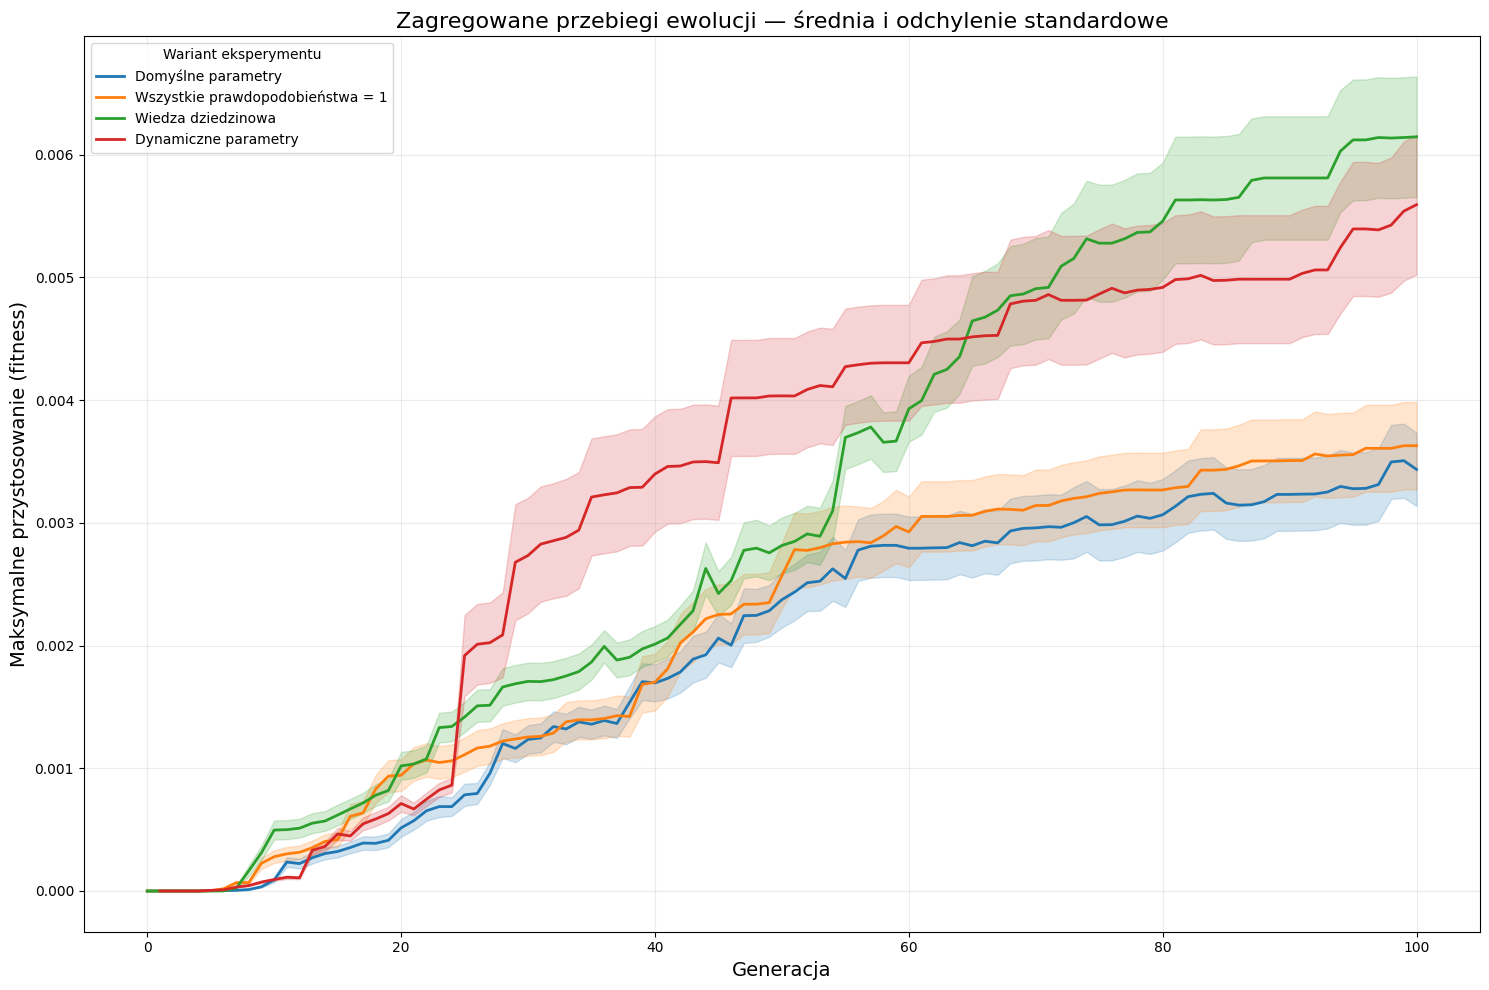

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("velocity_results.csv")

df_agg = df.groupby(["gen", "variant"])["max"].agg(["mean", "std"]).reset_index()

plt.figure(figsize=(15, 10), dpi=100)

variant_labels = {
    0: "Domyślne parametry",
    1: "Wszystkie prawdopodobieństwa = 1",
    2: "Wiedza dziedzinowa",
    3: "Dynamiczne parametry"
}

palette = sns.color_palette("tab10", n_colors=len(variant_labels))
SCALING_FACTOR = 10

for variant, color in zip(sorted(variant_labels), palette):
    df_temp = df_agg[df_agg["variant"] == variant]
    plt.plot(df_temp["gen"], df_temp["mean"],
             label=variant_labels[variant],
             color=color,
             linewidth=2)
    plt.fill_between(
        df_temp["gen"],
        df_temp["mean"] - df_temp["std"] / SCALING_FACTOR,
        df_temp["mean"] + df_temp["std"] / SCALING_FACTOR,
        color=color,
        alpha=0.2
    )

plt.title("Zagregowane przebiegi ewolucji — średnia i odchylenie standardowe", fontsize=16)
plt.xlabel("Generacja", fontsize=14)
plt.ylabel("Maksymalne przystosowanie (fitness)", fontsize=14)
plt.grid(alpha=0.25)
plt.legend(title="Wariant eksperymentu")
plt.tight_layout()
plt.savefig("przebiegi_ewolucji_zagregowane.png", dpi=200)
plt.show()

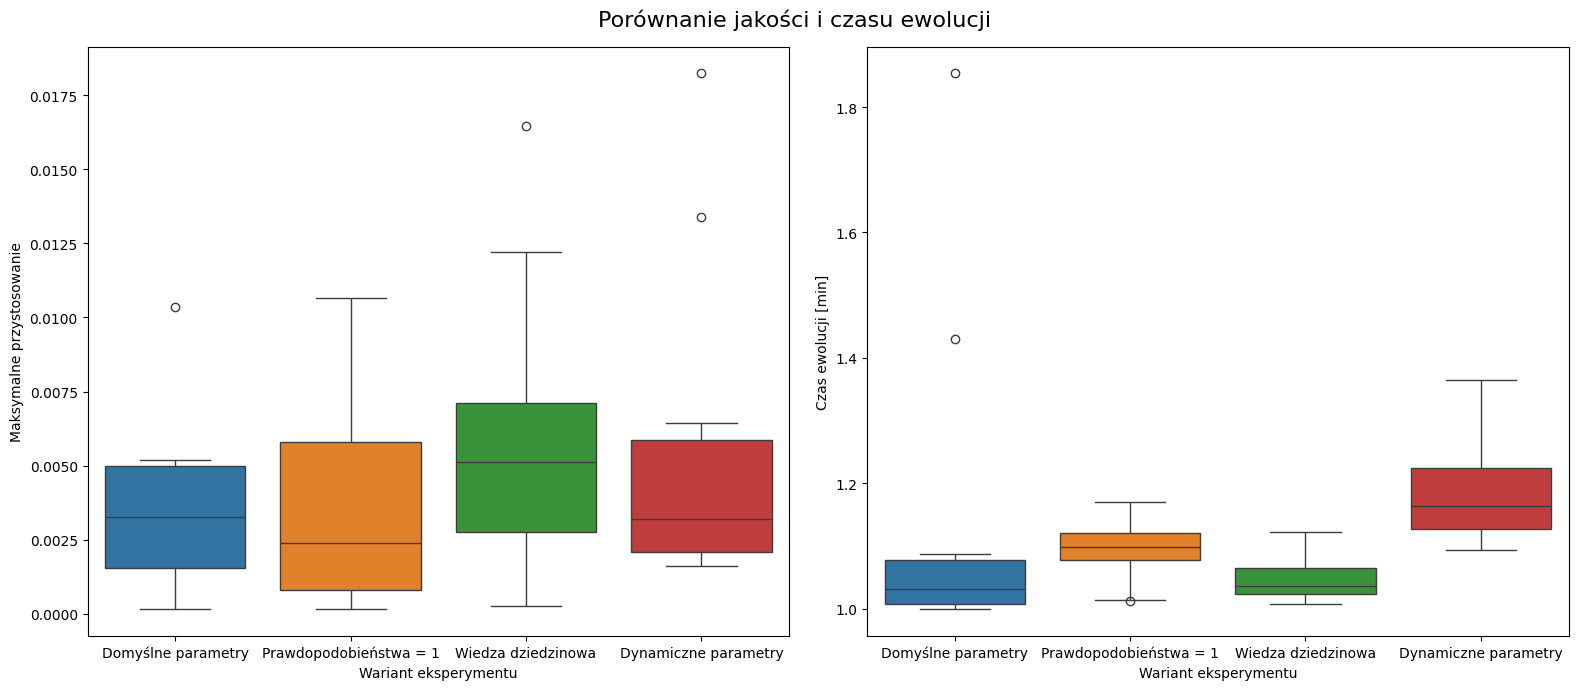

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("velocity_results.csv")
df_times = pd.read_csv("velocity_times.csv")

variant_labels = {
    0: "Domyślne parametry",
    1: "Prawdopodobieństwa = 1",
    2: "Wiedza dziedzinowa",
    3: "Dynamiczne parametry"
}

df_best = df.groupby(["variant", "iteration"], as_index=False)["max"].max()
df_best["variant_label"] = df_best["variant"].map(variant_labels)

df_times["elapsed_time"] /= 60
df_times["variant_label"] = df_times["variant"].map(variant_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), dpi=100)

palette = dict(zip(
    variant_labels.values(),
    sns.color_palette("tab10", n_colors=4)
))

sns.boxplot(
    ax=axes[0],
    x="variant_label",
    y="max",
    data=df_best,
    hue="variant_label",
    palette=palette,
    dodge=False,
    legend=False
)
axes[0].set_xlabel("Wariant eksperymentu")
axes[0].set_ylabel("Maksymalne przystosowanie")

sns.boxplot(
    ax=axes[1],
    x="variant_label",
    y="elapsed_time",
    data=df_times,
    hue="variant_label",
    palette=palette,
    dodge=False,
    legend=False
)
axes[1].set_xlabel("Wariant eksperymentu")
axes[1].set_ylabel("Czas ewolucji [min]")

plt.suptitle("Porównanie jakości i czasu ewolucji", fontsize=16)
plt.tight_layout()
plt.savefig("przebiegi_ewolucji_boxploty.png", dpi=200)
plt.show()

Do eksperymentu wybrano reprezentację **f1** i przeprowadzono optymalizację prędkości poruszania się zgodnie z przygotowanym schematem eksperymentu. W pierwszym etapie przetestowano trzy różne ustawienia prawdopodobieństw operatorów mutacji: domyślne, wszystkie ustawione na 1 oraz wartości dobrane intuicyjnie dla eksperymentu statycznego:
```
f1_smX:0.1
f1_smJunct:0.1
f1_smComma:0.1
f1_smModif:0.2
f1_nmNeu:0.1
f1_nmConn:0.2
f1_nmProp:0.15
f1_nmWei:0.05
f1_nmVal:0.05
```

Takie ustawienie daje większy udział operacjom odpowiadającym za rozwój konstrukcji osobników oraz tworzenie neuronów, a mniejszy mutacjom dotyczącym połączeń między neuronami i wartości wag. Celem było zachowanie równowagi między eksploracją przestrzeni genotypowej a dopracowywaniem istniejącej sieci neuronowej.

Esperyment dynamiczny przeprowadzono w trzech fazach. Idea algorytmu trójfazowego opiera się na kolejnych etapach rozwoju populacji: w pierwszej fazie największy udział mają mutacje odpowiedzialne za rozwój konstrukcji i tworzenie neuronów, w drugiej fazie skupiamy się na tworzeniu połączeń między istniejącymi neuronami i dobieraniu parametrów, a w trzeciej fazie następuje „uczenie” sieci poprzez dobór odpowiednich wag połączeń i wartości funkcji w neuronach.

Dynamiczne podejście trójfazowe zapewnia najlepsze efekty końcowe, a intuicyjne statyczne prawdopodobieństwa również daje bardzo dobre wyniki, przewyższając wariant z równymi prawdopodobieństwami. Wariant z wszystkimi prawdopodobieństwami równymi 1 czasami generował pojedynczych bardzo dobrych osobników, co podciągało średnią, jednak w praktyce nie zapewniał stabilnych postępów populacji. Ostatecznie wyniki pokazują, że etapowa optymalizacja i odpowiednie dopasowanie prawdopodobieństw mutacji, zarówno dynamiczne jak i starannie dobrane statyczne, pozwalają efektywnie eksplorować przestrzeń rozwiązań i rozwijać konstrukcję osobników wraz z ich siecią neuronową. Prawdopodobnie da się jednak znaleźć jeszcze lepsze parametry niż te wskazane w eksperymencie. Być może warto zastosować inny algorytm optymalizacyjny do znalezienia tych najlepszych wartości.